In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os



In [11]:
sst = xr.open_dataset('/home/disk/mercury2/nacc/AIMIP2026/DLESyM/aimip/forcing_data/ERA5-0.25deg-monthly-mean-forcing-1978-2024.nc').sea_surface_temperature
lsm = xr.open_dataset('/home/disk/mercury2/nacc/AIMIP2026/DLESyM/aimip/forcing_data/ERA5-0.25deg-monthly-mean-forcing-1978-2024.nc').land_sea_mask
print(sst)
print(lsm)

<xarray.DataArray 'sea_surface_temperature' (time: 556, latitude: 721,
                                             longitude: 1440)>
[577261440 values with dtype=float32]
Coordinates:
  * latitude   (latitude) float32 90.0 89.75 89.5 89.25 ... -89.5 -89.75 -90.0
  * longitude  (longitude) float32 0.0 0.25 0.5 0.75 ... 359.0 359.2 359.5 359.8
  * time       (time) datetime64[ns] 1978-10-01 1978-11-01 ... 2025-01-01
<xarray.DataArray 'land_sea_mask' (latitude: 721, longitude: 1440)>
[1038240 values with dtype=float32]
Coordinates:
  * latitude   (latitude) float32 90.0 89.75 89.5 89.25 ... -89.5 -89.75 -90.0
  * longitude  (longitude) float32 0.0 0.25 0.5 0.75 ... 359.0 359.2 359.5 359.8


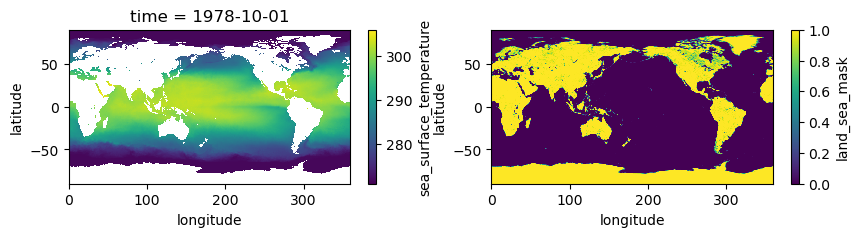

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(10, 2))

# plot first timestep of sst and lsm
sst.isel(time=0).plot(ax=ax[0])
lsm.plot(ax=ax[1])
plt.show()



Let's see how these compare to the data DLESyM was trained on. Also a sanity check to make sure we're getting what we expect. 

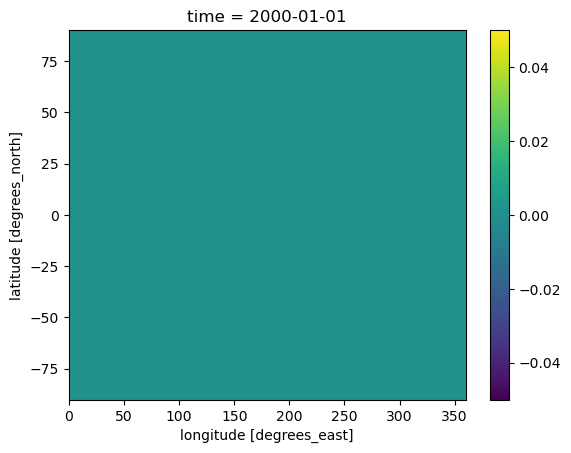

In [19]:
# open lsm from training data
lsm_train = xr.open_dataset('/home/disk/rhodium/dlwp/data/era5/0.25deg/era5_1950-2022_3h_0.25deg_lsm.nc').lsm
lsm_diff = lsm_train - lsm
# plot lsm from training data
lsm_diff.plot()
plt.show()



OK, so we're confident that these datasets are well aligned with training data and proprocessing should be minimal